# Twitter Network Analysis
This notebook contains a social network analysis mainly executed with the library of NetworkX. In detail, this dataset consists of 'circles' (or 'lists') from Twitter. Twitter data was crawled from public sources. The dataset includes node features (profiles), circles, and ego networks. The dataset can be found at this link: [Stanford Twitter Dataset](https://snap.stanford.edu/data/ego-Twitter.html).

## Import packages

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import randint

%matplotlib inline

## Analysis
The edges are loaded from the `data` folder and saved in a dataframe. Each edge is a new row and for each edge there is a `start_node` and an `end_node` column

In [ ]:
twitter = pd.read_csv(
    "https://snap.stanford.edu/data/twitter_combined.txt.gz",
    compression="gzip",
    sep=" ",
    names=["start_node", "end_node"],
)
twitter = twitter.iloc[:80000]

The graph is created from the `twitter` dataframe of the edges:

In [ ]:
G = nx.from_pandas_edgelist(twitter, "start_node", "end_node")

## Visualizing the graph

Let's start our exploration by visualizing the graph. Visualization plays a
central role in exploratory data analysis to help get a qualitative feel for
the data.

Since we don't have any real sense of structure in the data, let's start by
viewing the graph with `random_layout`, which is among the fastest of the layout
functions.

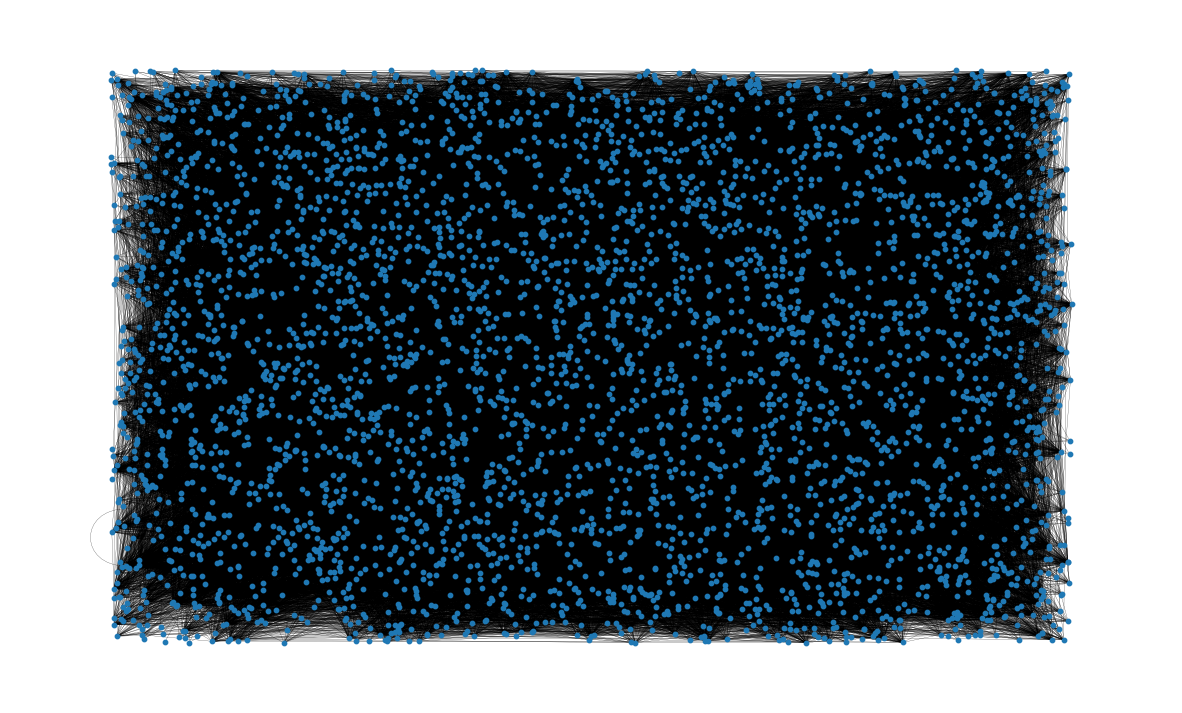

In [ ]:
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
nx.draw_networkx(G, pos=nx.random_layout(G), ax=ax, **plot_options)

Do we need more or less information (nodes or edges) from the graph to do the analysis? Let's check `spring_layout` and continue analysis...

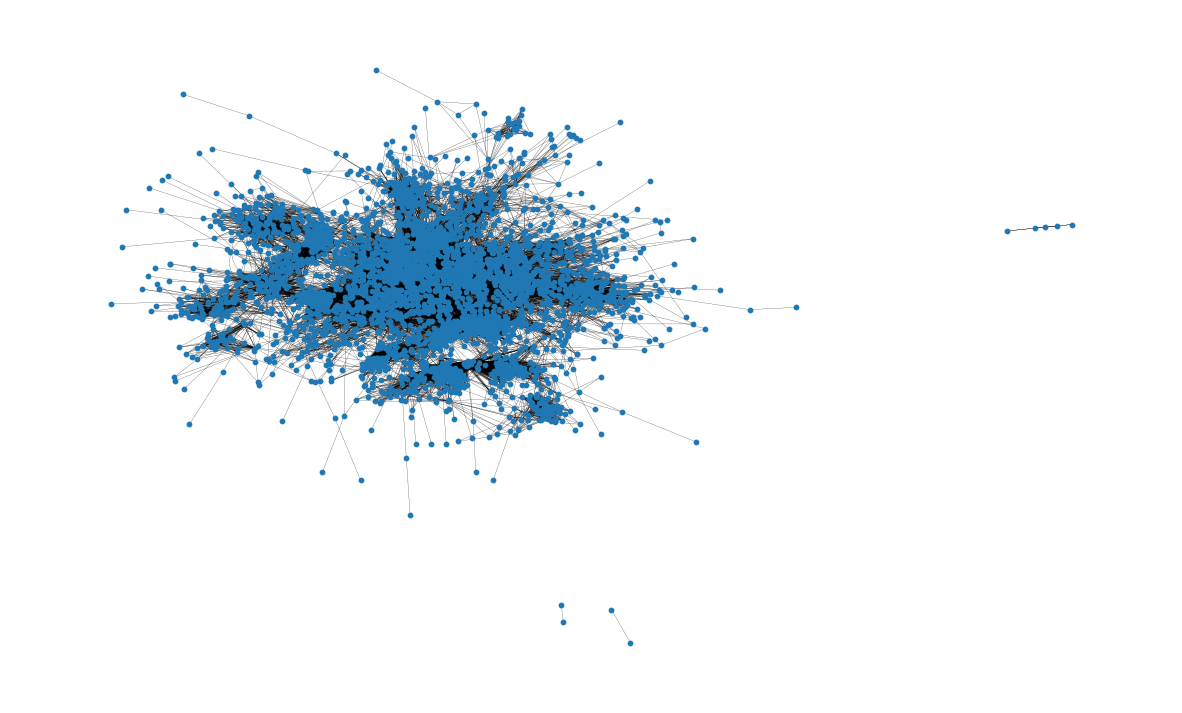

In [ ]:
pos = nx.spring_layout(G, iterations=15, seed=1721)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
nx.draw_networkx(G, pos=pos, ax=ax, **plot_options)

What other information can we extract from this network? ... (check graphs metrics)

##Atributos Básicos

Número de nodos

In [ ]:
G.number_of_nodes()

4316

Número de ejes

In [ ]:
G.number_of_edges()

58270

Además, se puede observar el grado promedio de un nodo. En promedio, un nodo está conectado a casi 27 otros nodos, también conocidos como vecinos del nodo.

Esto se ha calculado creando una lista con todos los grados de los nodos y utilizando numpy.array para encontrar la media de la lista creada.

In [ ]:
np.mean([d for _, d in G.degree()])

np.float64(27.00185356811863)

Ahora, el diámetro de un grafo representa el más largo de los caminos más cortos que conectan cualquier nodo con otro nodo en el grafo.
De manera similar, la longitud promedio del camino da una medida del número promedio de aristas que se deben recorrer para ir de un nodo a otro en la red.
Estos atributos pueden calcularse con las funciones nx.diameter y nx.average_shortest_path_length, respectivamente.
Sin embargo, estos análisis requieren calcular el camino más corto entre cada par de nodos en la red lo cual tiene un gasto computacional alto
Dado que nos interesan varios análisis que implican la longitud del camino más corto para todos los nodos de la red, podemos calcular esto una vez y reutilizar la información para ahorrar tiempo de cómputo.

Comencemos calculando la longitud del camino más corto para todos los pares de nodos en la red:

In [ ]:
shortest_path_lengths = dict(nx.all_pairs_shortest_path_length(G))

por ejemplo, de ir del nodo 1 al cuatro no hay camino

In [ ]:
# Check if nodes 1 and 4 exist in the graph
if 1 in G.nodes() and 4 in G.nodes():
    # If both nodes exist, then calculate the shortest path length
    shortest_path_length = shortest_path_lengths.get(1, {}).get(4)
    if shortest_path_length is not None:
        print(f"Length of shortest path between nodes 1 and 4: {shortest_path_length}")
    else:
        print("There is no path between nodes 1 and 4.")
else:
    # If either node does not exist, print an informative message
    print("Either node 1 or node 4 (or both) do not exist in the graph.")

Either node 1 or node 4 (or both) do not exist in the graph.


Ahora usemos shortest_path_lengths para realizar nuestros análisis, comenzando con el diámetro de G.
Si observamos cuidadosamente la [documentación de nx.diameter][nx_diameter_], veremos que es equivalente a la excentricidad máxima del grafo.
Resulta que nx.eccentricity tiene un argumento opcional sp donde podemos pasar nuestras shortest_path_lengths precomputadas para ahorrar el cálculo adicional.

In [ ]:
# This is equivalent to `diameter = nx.diameter(G)`, but much more efficient since we're
# reusing the pre-computed shortest path lengths!
# Get the largest connected component subgraph
largest_cc = max(nx.connected_components(G), key=len)
G_connected = G.subgraph(largest_cc)

# Calculate the diameter on the connected component
diameter = max(nx.eccentricity(G_connected, sp=shortest_path_lengths).values())
diameter

16

Para conectar un nodo con cualquier otro, tendríamos que atravesar 16 aristas o menos.

A continuación, se encuentra la longitud promedio del camino.
Nuevamente, podríamos usar nx.average_shortest_path_length para calcular esto directamente, pero es mucho más eficiente usar los shortest_path_length que ya hemos calculado.

In [ ]:
# Compute the average shortest path length for each node
average_path_lengths = [
    np.mean(list(spl.values())) for spl in shortest_path_lengths.values()
]
# The average over all nodes
np.mean(average_path_lengths)

np.float64(4.837700405033223)

Esto representa el promedio de la longitud del camino más corto para todos los pares de nodos:
para ir de un nodo a otro, se recorrerán en promedio aproximadamente 4.8 aristas.

Las medidas anteriores capturan información útil sobre la red, pero métricas como el valor promedio representan solo un aspecto de la distribución;
también suele ser valioso observar la distribución en sí misma.
Nuevamente, podemos construir una visualización de la distribución de las longitudes de los caminos más cortos a partir de nuestro diccionario de diccionarios previamente calculado

Text(0, 0.5, 'Frequency (%)')

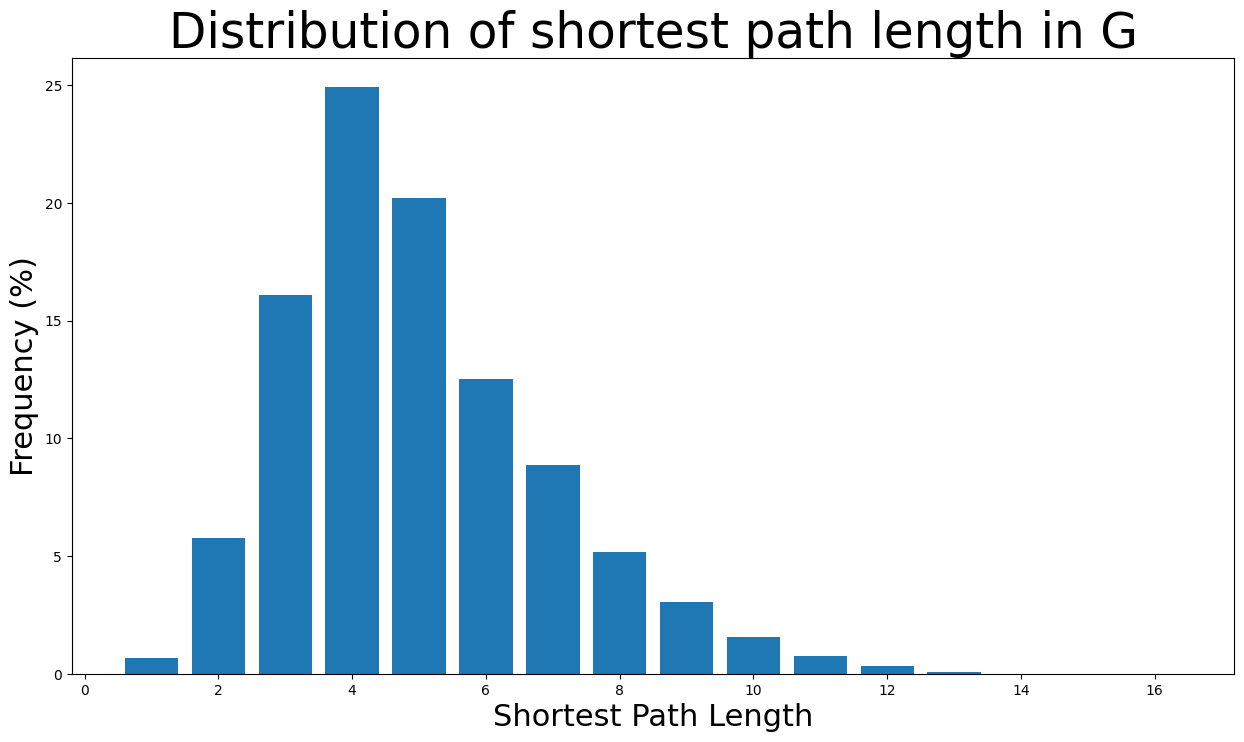

In [ ]:
# We know the maximum shortest path length (the diameter), so create an array
# to store values from 0 up to (and including) diameter
path_lengths = np.zeros(diameter + 1, dtype=int)

# Extract the frequency of shortest path lengths between two nodes
for pls in shortest_path_lengths.values():
    pl, cnts = np.unique(list(pls.values()), return_counts=True)
    path_lengths[pl] += cnts

# Express frequency distribution as a percentage (ignoring path lengths of 0)
freq_percent = 100 * path_lengths[1:] / path_lengths[1:].sum()

# Plot the frequency distribution (ignoring path lengths of 0) as a percentage
fig, ax = plt.subplots(figsize=(15, 8))
ax.bar(np.arange(1, diameter + 1), height=freq_percent)
ax.set_title(
    "Distribution of shortest path length in G", fontdict={"size": 35}, loc="center"
)
ax.set_xlabel("Shortest Path Length", fontdict={"size": 22})
ax.set_ylabel("Frequency (%)", fontdict={"size": 22})

La mayoría de las longitudes de los caminos más cortos tienen entre 3 y 6 aristas.
Además, es muy poco probable que un par de nodos tenga un camino más corto de longitud 12 (la longitud del diámetro)

Aquí se calcula la densidad del grafo. Claramente, el grafo es muy disperso ya que: densidad < 1.

In [ ]:
nx.density(G)

0.0062576717423218145

El número de componentes del grafo se encuentra a continuación. Como se esperaba, la red consiste en siete componentes principales:

In [ ]:
nx.number_connected_components(G)

7

## Medidas de centralidad

### Centralidad de Grado
La centralidad de grado asigna una puntuación de importancia basada simplemente en el número de enlaces que tiene cada nodo. para la data entre más centralidad tiene es porque mas conecciones tiene en la red social

Para comenzar, encontramos los nodos con las centralidades de grado más altas. Específicamente, los nodos con las 5 centralidades de grado más altas se muestran a continuación junto con su valor de centralidad de grado:

In [ ]:
degree_centrality = nx.centrality.degree_centrality(
    G
)  # save results in a variable to use again
(sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True))[:5]

[(48485771, 0.07022016222479723),
 (5442012, 0.06813441483198146),
 (3359851, 0.06581691772885284),
 (40981798, 0.06257242178447277),
 (43003845, 0.0593279258400927)]

Eso significa que el nodo $48485771$ tiene la centralidad de grado más alta con un valor de $0.07$, lo que indica que este usuario de Twiter tiene conexions con alrededor del 7% de la red

Los otros 4 nodos tienen conexiones con alrededor del 6% de la red cada uno.

Ahora también podemos ver el número de vecinos para los nodos con las centralidades de grado más altas:

In [ ]:
(sorted(G.degree, key=lambda item: item[1], reverse=True))[:5]

[(48485771, 303),
 (5442012, 294),
 (3359851, 284),
 (40981798, 270),
 (43003845, 256)]

El nodo con mayor centralidad tiene 303 conexiones en twiter, lo cual es la mayor cantidad que tiene cualquier usuario en este análisis.

Los otros 4 tienen valores entre 294 y  256

Ahora se graficará la distribución de las centralidades de grado:

Text(0, 0.5, 'Counts')

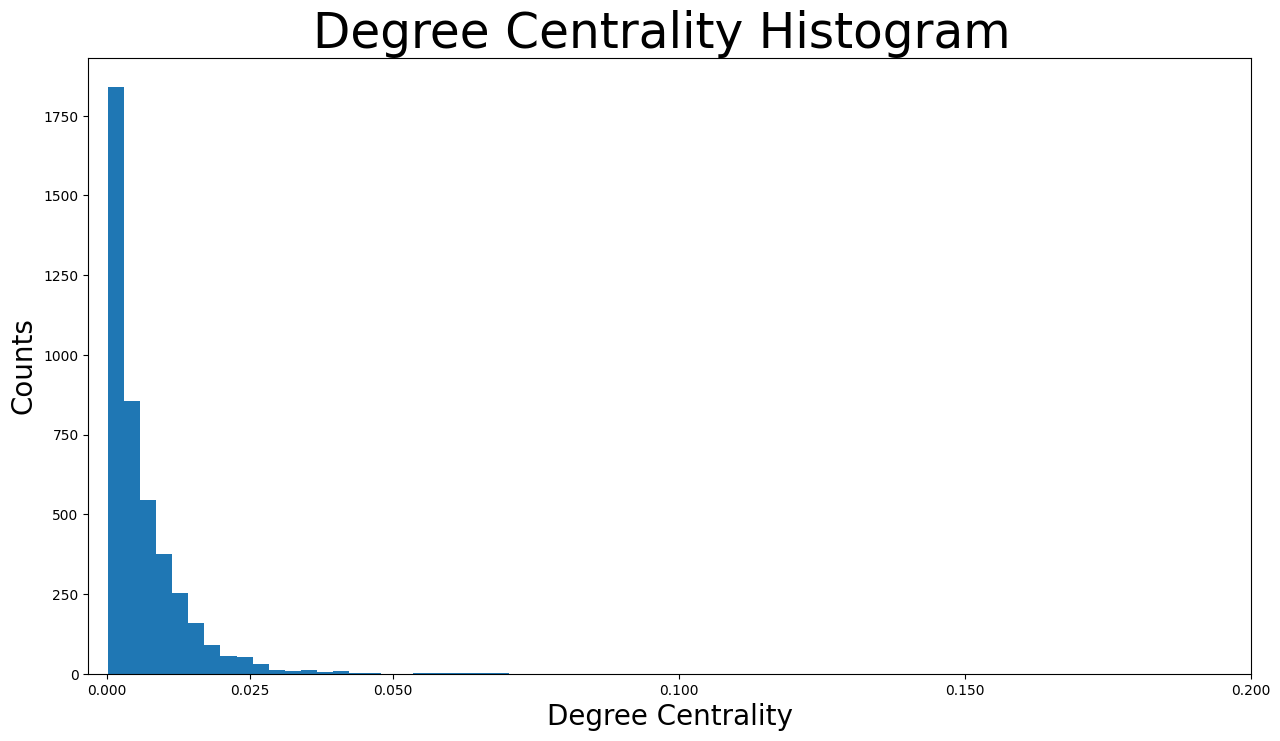

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(degree_centrality.values(), bins=25)
plt.xticks(ticks=[0, 0.025, 0.05, 0.1, 0.15, 0.2])  # set the x axis ticks
plt.title("Degree Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Degree Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

Es evidente que la gran mayoría de los usuarios de Facebook tienen centralidades de grado menores a $0.025$.
Ahora vamos a revisar los usuarios con las mayores centralidades de grado según el tamaño de sus nodos:

(np.float64(-0.6459476724267006),
 np.float64(1.1564022675156593),
 np.float64(-1.0558947339653968),
 np.float64(0.7013561144471169))

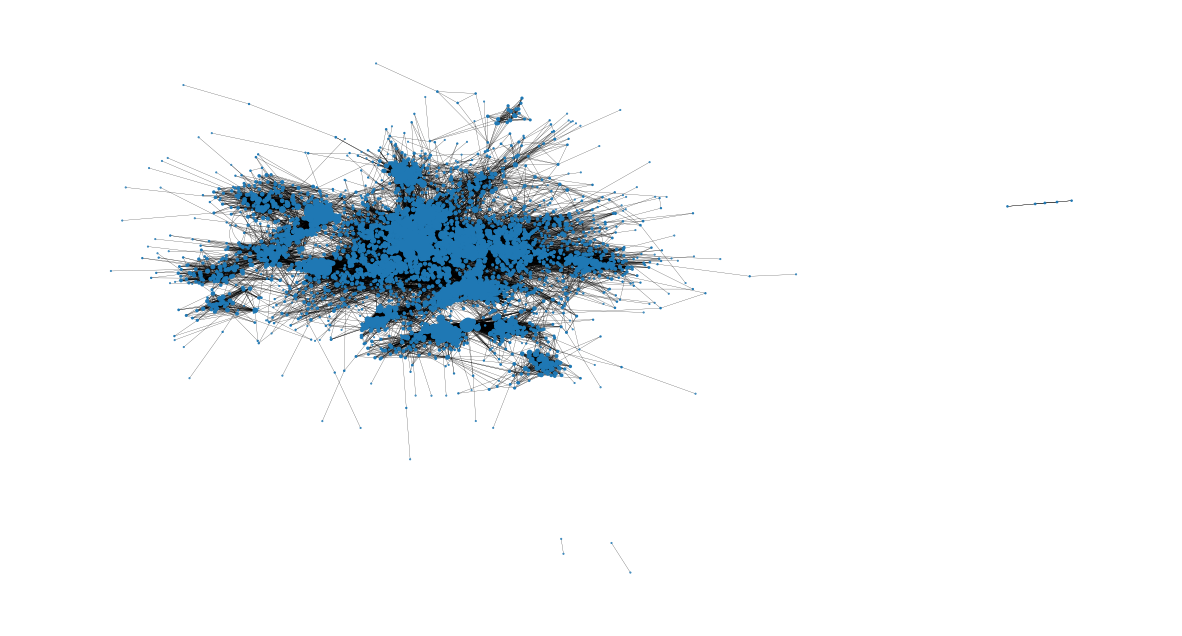

In [ ]:
node_size = [
    v * 1000 for v in degree_centrality.values()
]  # set up nodes size for a nice graph representation
plt.figure(figsize=(15, 8))
nx.draw_networkx(G, pos=pos, node_size=node_size, with_labels=False, width=0.15)
plt.axis("off")

### Centralidad de Intermediación
La centralidad de intermediación mide cuántas veces un nodo se encuentra en el camino más corto entre otros nodos, lo que significa que actúa como un puente.  Un usuario con una alta centralidad de intermediación actúa como un puente para muchos usuarios que no son amigos y, por lo tanto, tiene la capacidad de influir en ellos al transmitir información
Ahora, se calcularán los nodos con las 5 centralidades de intermediación más altas y se mostrarán junto con sus valores de centralidad:

In [ ]:
betweenness_centrality = nx.centrality.betweenness_centrality(
    G
)  # save results in a variable to use again
(sorted(betweenness_centrality.items(), key=lambda item: item[1], reverse=True))[:5]

[(6207392, 0.1725645640056724),
 (3359851, 0.15443758920551148),
 (783214, 0.0975291202117271),
 (41716273, 0.09272687817377762),
 (17093617, 0.09073724589851986)]

Al observar los resultados, el nodo $107$ tiene una centralidad de intermediación de $0.48$, lo que significa que se encuentra en casi la mitad de los caminos más cortos entre otros nodos. Además, combinando el conocimiento de la centralidad de grado:

El nodo 3359851esta tanto en mayores centralidades
como de intermediación y son nodos destacados. Esto indica que esos nodos son tanto los más populares de la red como los que pueden influir y difundir información en la red.

Los tros 4 nodos encontrados no tienen las mayores centralidades de grado. Esto significa que, aunque esos nodos no son los usuarios más populares de la red, tienen la mayor influencia en esta red entre los amigos de los nodos destacados en lo que respecta a la difusión de información.

Los otros 4 nodos con una centralidad de intermediación muy alta, aunque no tiene las mayores centralidades de grado. En otras palabras, este nodo no tiene una lista conexiones muy grande pero con poca influencia.

Continuamos, ahora se graficará la distribución de las centralidades de intermediación:

Text(0, 0.5, 'Counts')

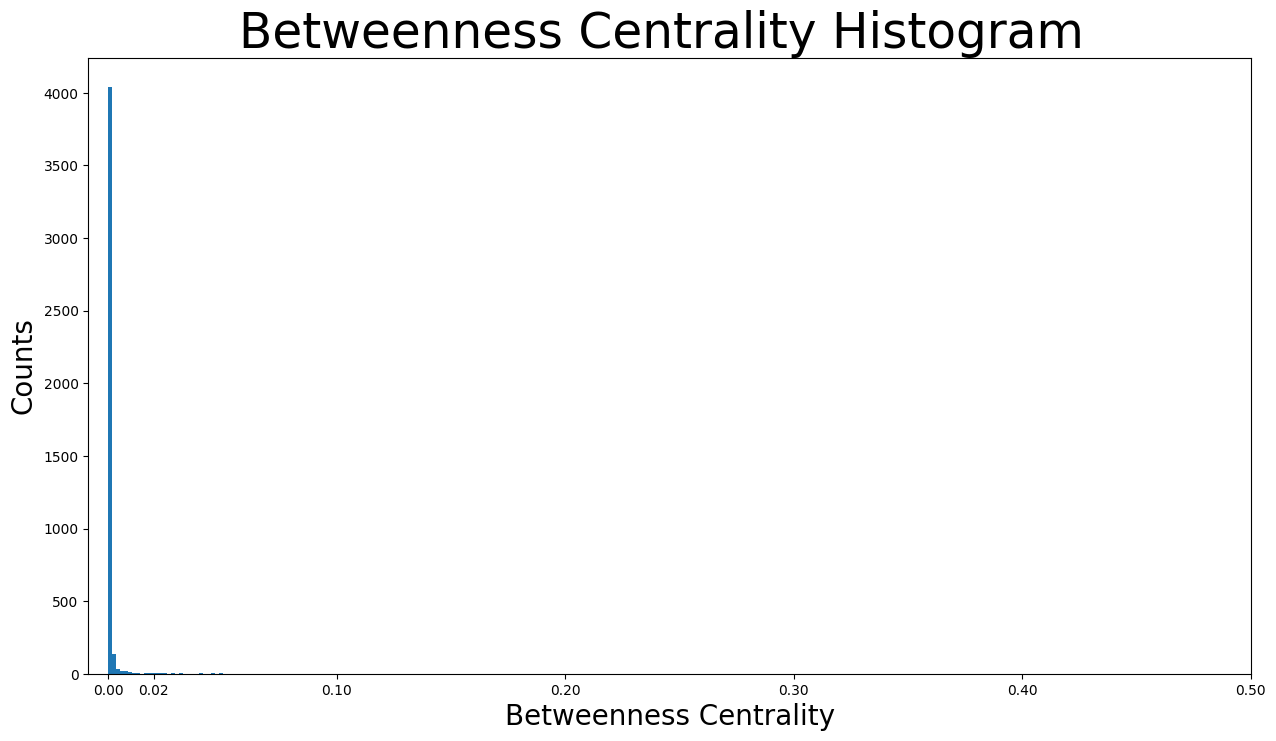

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(betweenness_centrality.values(), bins=100)
plt.xticks(ticks=[0, 0.02, 0.1, 0.2, 0.3, 0.4, 0.5])  # set the x axis ticks
plt.title("Betweenness Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Betweenness Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

Como podemos ver, la gran mayoría de las centralidades de intermediación están por debajo de $0.001$. Esto tiene sentido, ya que el grafo es muy disperso y, por lo tanto, la mayoría de los nodos no actúan como puentes en los caminos más cortos.

También podemos obtener una visión de los nodos con las mayores centralidades de intermediación y su ubicación en la red. Es claro que estos nodos son los puentes entre una comunidad y otra:

(np.float64(-0.6459476724267006),
 np.float64(1.1564022675156593),
 np.float64(-1.0558947339653968),
 np.float64(0.7013561144471169))

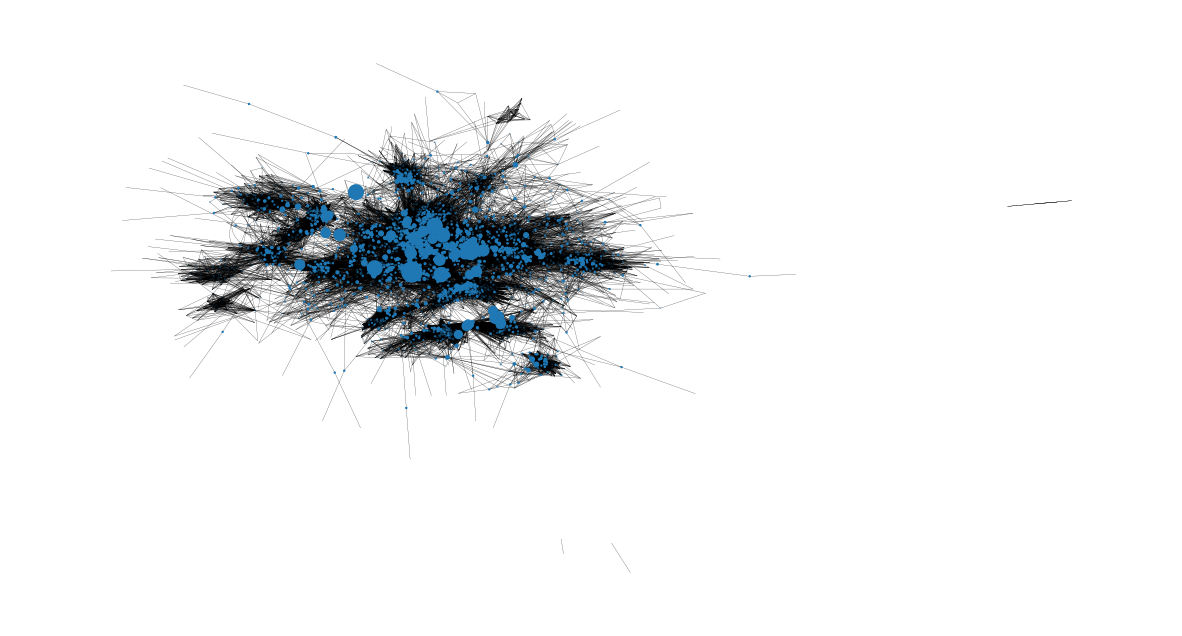

In [ ]:
node_size = [
    v * 1200 for v in betweenness_centrality.values()
]  # set up nodes size for a nice graph representation
plt.figure(figsize=(15, 8))
nx.draw_networkx(G, pos=pos, node_size=node_size, with_labels=False, width=0.15)
plt.axis("off")

### Centralidad de Cercanía
La centralidad de cercanía asigna un puntaje a cada nodo basado en su "cercanía" con todos los demás nodos de la red. Es decir,cuanto más cerca está ubicado del centro de la red.

La medida de centralidad de cercanía es muy importante para monitorear la propagación de información falsa (por ejemplo, noticias falsas) o virus (por ejemplo, enlaces maliciosos que toman control de la cuenta de Facebook en este caso). Examinemos el ejemplo de noticias falsas. Si el usuario con la medida más alta de centralidad de cercanía comenzara a difundir información falsa (compartiendo o creando una publicación), toda la red se desinformaría lo más rápido posible. Sin embargo, si un usuario con una centralidad de cercanía muy baja intentara lo mismo, la propagación de la desinformación a toda la red sería mucho más lenta. Esto se debe a que la información falsa primero tendría que llegar a un usuario con alta centralidad de cercanía que la difundiría a muchas partes diferentes de la red.

Ahora se encontrarán los nodos con las más altas centralidades de cercanía:

In [ ]:
closeness_centrality = nx.centrality.closeness_centrality(
    G
)  # save results in a variable to use again
(sorted(closeness_centrality.items(), key=lambda item: item[1], reverse=True))[:8]

[(3359851, 0.3174907000782523),
 (15234657, 0.2989200839846593),
 (48485771, 0.2947102540271258),
 (7860742, 0.293730499193259),
 (15666380, 0.2907448655999966),
 (20880546, 0.29061735524303445),
 (3829151, 0.2868847706962951),
 (115485051, 0.2850950836856413)]

Inspeccionando a los usuarios con las mayores centralidades de cercanía, entendemos que no existe una gran diferencia entre ellos, en contraste con las métricas anteriores. Además, el nodo 3359851 se encuentra entre aquellos con las centralidades de cercanía más altas. Esto significa que un nodo que tiene muchos amigos no necesariamente está cerca del centro de la red.

Text(0, 0.5, 'Counts')

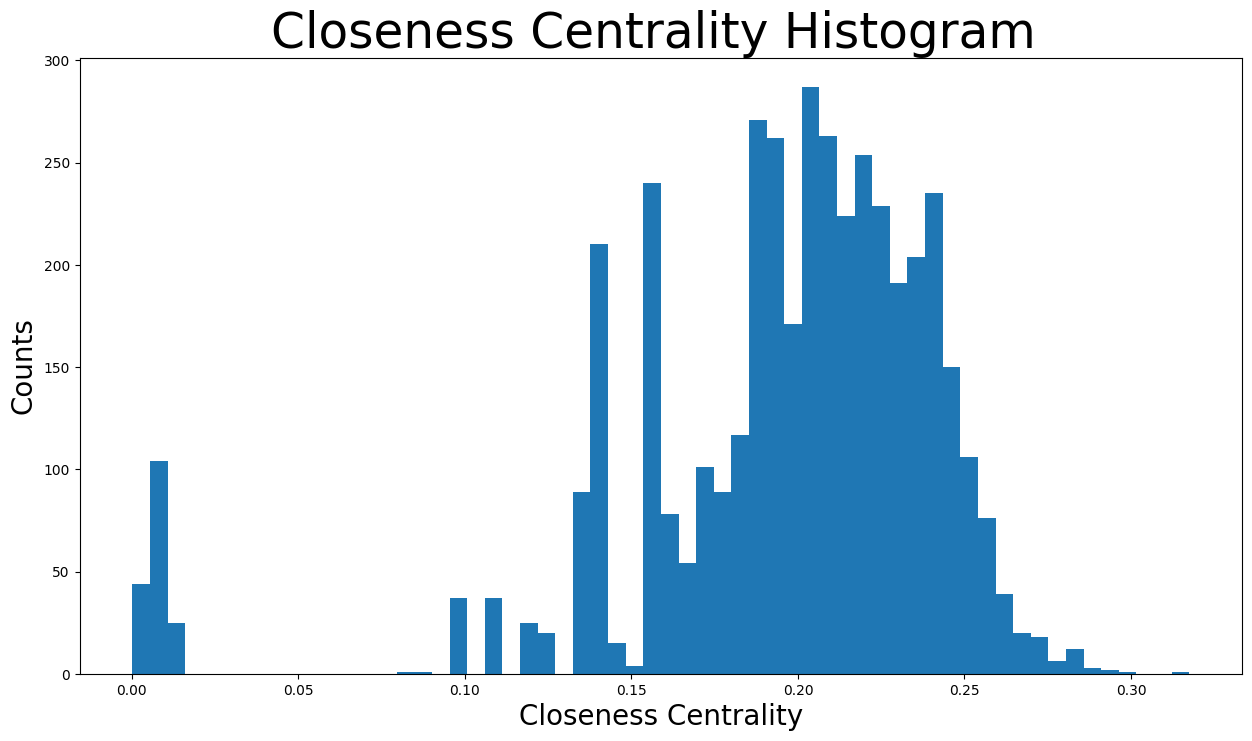

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(closeness_centrality.values(), bins=60)
plt.title("Closeness Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Closeness Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

Las centralidades de cercanía están distribuidas en varios valores, desde $0.57$ hasta $0.30$. Esto significa que la mayoría de los nodos están relativamente cerca del centro de la red y, por tanto, cerca de otros nodos en general. Sin embargo, existen algunas comunidades que están ubicadas más lejos, cuyos nodos presentan las centralidades de cercanía más bajas.

### Centralidad de Vector Propio (Eigenvector Centrality)
La centralidad de vector propio es una métrica que muestra qué tan conectado está un nodo con otros nodos importantes en la red.  Esta medida permite identificar los nodos con mayor influencia en toda la red.

En este análisis de twiter, esta métrica se asocia con la capacidad de un usuario para influir en toda la red.

Ahora se examinarán los nodos con las centralidades de vector propio más altas:

In [ ]:
eigenvector_centrality = nx.centrality.eigenvector_centrality(
    G
)  # save results in a variable to use again
(sorted(eigenvector_centrality.items(), key=lambda item: item[1], reverse=True))[:5]

[(40981798, 0.15363590744821665),
 (43003845, 0.1507372702636457),
 (22462180, 0.14898138833635383),
 (34428380, 0.14836888505482648),
 (153226312, 0.11747403879993272)]

Revisando los resultados:

El nodo $40981798$ tiene la mayor centralidad de vector propio con un valor de $0.15$. Es el nodo más importante de esta red en términos de influencia general.

 Lo interesante es que todos estos nodos son identificados por primera vez en este análisis, lo que significa que no tienen las centralidades más altas en grado, intermediación ni cercanía. Esto lleva a la conclusión de que es muy probable que estos nodos estén conectados directamente al nodo 3359851 y, como resultado, tengan valores tan altos de centralidad de vector propio.


Veamos la distribución de las centralidades de eigenvector

Text(0, 0.5, 'Counts')

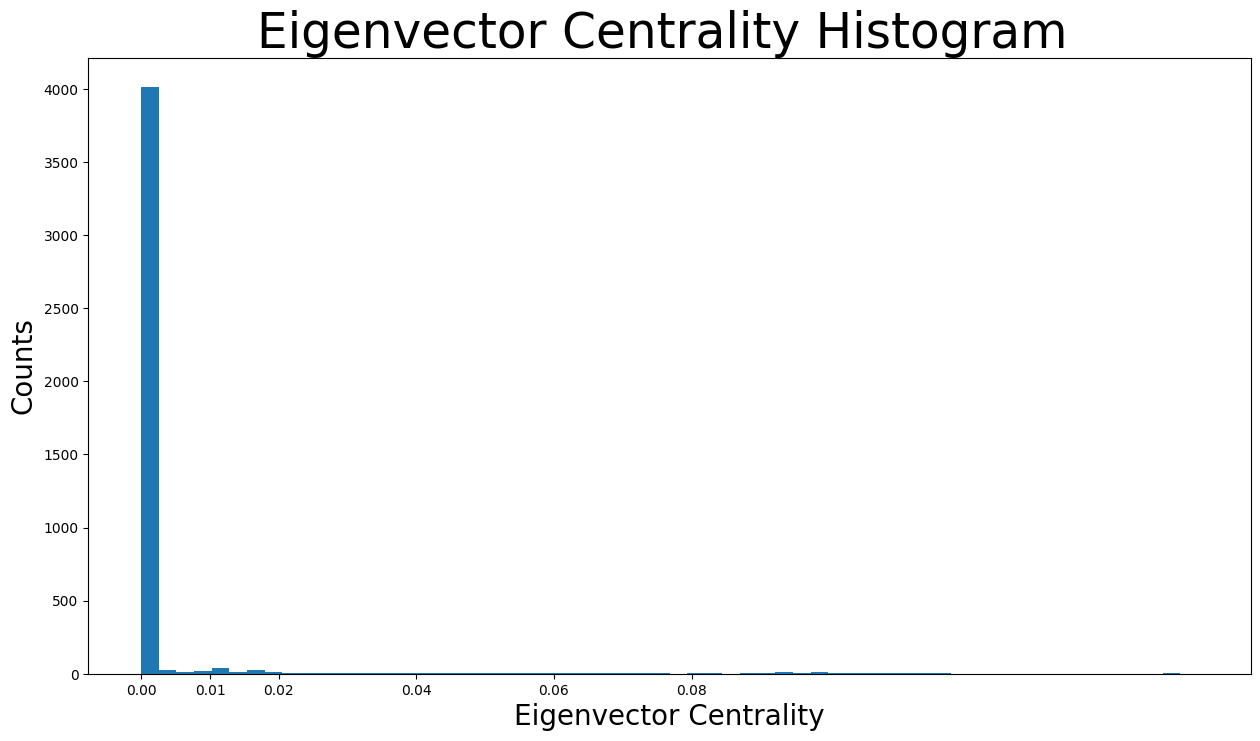

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(eigenvector_centrality.values(), bins=60)
plt.xticks(ticks=[0, 0.01, 0.02, 0.04, 0.06, 0.08])  # set the x axis ticks
plt.title("Eigenvector Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Eigenvector Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

Como se muestra en el histograma de distribución, la gran mayoría de las centralidades de eigenvector están por debajo de $0.001$ y de hecho son casi 0

Ahora podemos identificar las centralidades de eigenvector de los nodos según su tamaño en la siguiente representación:"

(np.float64(-0.6459476724267006),
 np.float64(1.1564022675156593),
 np.float64(-1.0558947339653968),
 np.float64(0.7013561144471169))

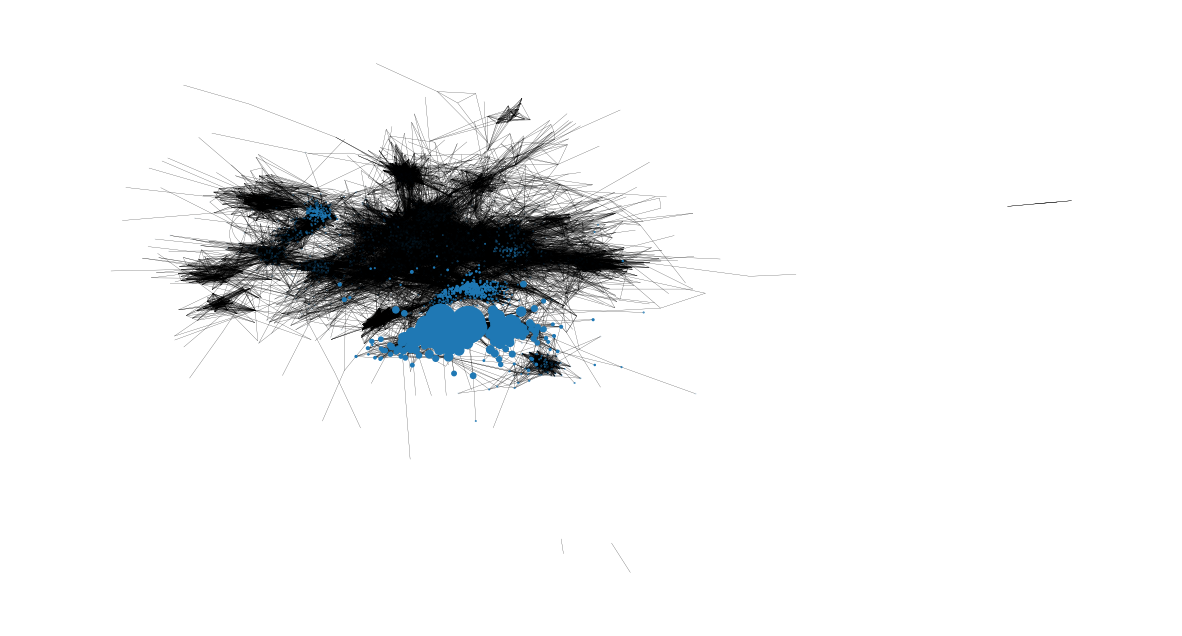

In [ ]:
node_size = [
    v * 4000 for v in eigenvector_centrality.values()
]  # set up nodes size for a nice graph representation
plt.figure(figsize=(15, 8))
nx.draw_networkx(G, pos=pos, node_size=node_size, with_labels=False, width=0.15)
plt.axis("off")

## Efectos de Agrupamiento (Clustering Effects)
El coeficiente de agrupamiento de un nodo se define como la probabilidad de que dos amigos seleccionados aleatoriamente de otro sean amigos entre sí. Cuanto más cercano esté este valor a $1$, más completo será el grafo, ya que habrá un único componente gigante.

In [ ]:
nx.average_clustering(G)

0.4949716847236492

la distribución dle coeficiente se graficara

Text(0, 0.5, 'Counts')

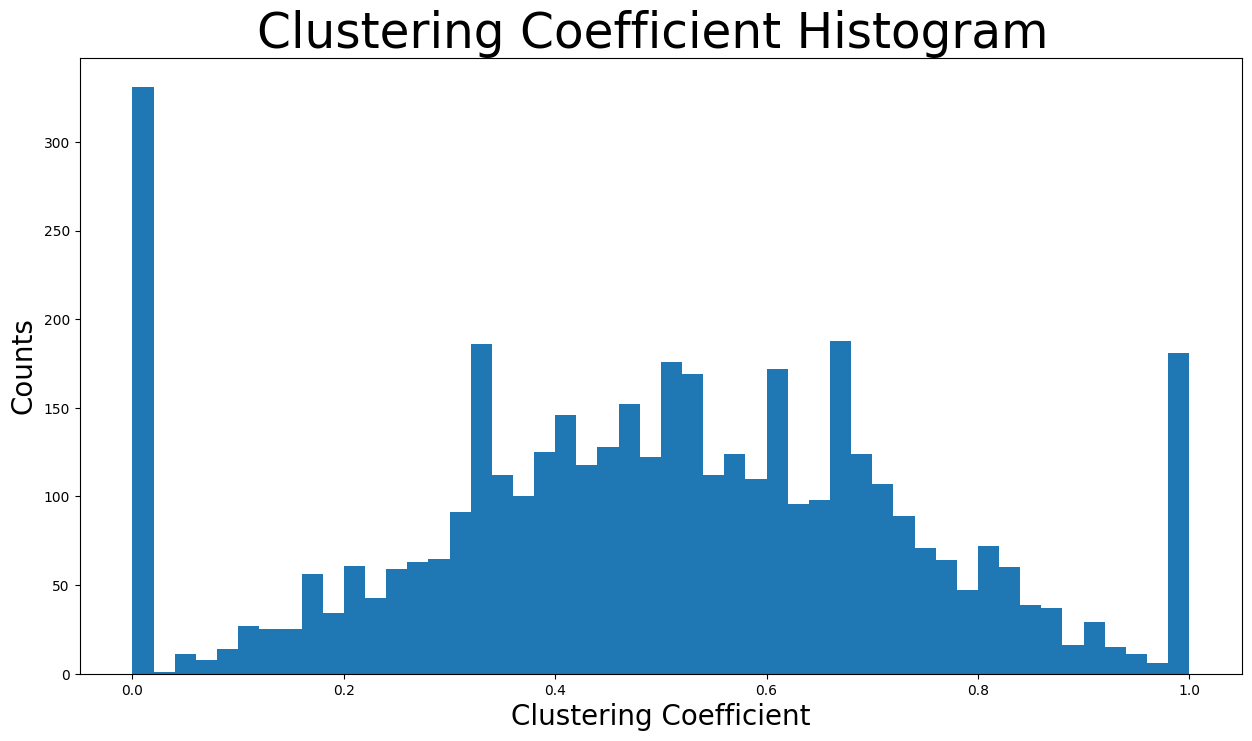

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(nx.clustering(G).values(), bins=50)
plt.title("Clustering Coefficient Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Clustering Coefficient", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

l intervalo con el mayor número de elementos corresponde a los nodos con un coeficiente de agrupamiento cercano a $0$, ya que hay más de 300

 Además, los intervalos de coeficiente de agrupamiento entre $0.02$ y $0.8$ contienen, por mucho, la mayoría de los nodos.

A continuación, se encuentra el número de triángulos únicos en la red:"

In [ ]:
triangles_per_node = list(nx.triangles(G).values())
sum(
    triangles_per_node
) / 3  # divide by 3 because each triangle is counted once for each node

465759.0

Ahora el numero de triangulos promedio en el que un nodo hace parte

In [ ]:
np.mean(triangles_per_node)

np.float64(323.7435125115848)

Debido a que algunos nodos pertenecen a muchos triángulos, la métrica de la mediana nos dará una mejor comprensión

In [ ]:
np.median(triangles_per_node)

np.float64(71.0)

De hecho, el valor de la mediana es de 71 triángulos, mientras que la media es alrededor de 465759 triángulos en los que un nodo está involucrado. Eso significa que la mayoría de los nodos de la red pertenecen a muy pocos triángulos, mientras que algunos nodos son parte de una gran cantidad de triángulos (lo que son valores extremos que aumentan la media).

En conclusión, el alto coeficiente de agrupamiento promedio junto con el gran número de triángulos son señales de cierre triádico. En detalle, el cierre triádico significa que, a medida que pasa el tiempo, tienden a formarse nuevos enlaces entre dos usuarios que tienen uno o más amigos en común.

## Puentes
En primer lugar, un borde que une dos nodos A y B en el grafo se considera un puente si eliminar el borde causaría que A y B se encuentren en dos componentes diferentes. Ahora se verifica si existen puentes en esta red:

In [ ]:
nx.has_bridges(G)

True

si hay puentes y se mira el número

In [ ]:
bridges = list(nx.bridges(G))
len(bridges)

209

Además, los bordes que son puentes locales se guardan en una lista y se imprime su número. En detalle, un borde que une dos nodos en un grafo es un puente local, si sus puntos finales no tienen amigos en común

In [ ]:
local_bridges = list(nx.local_bridges(G, with_span=False))
len(local_bridges)

987

Mostrando los puentes y los puentes locales en la red ahora. Los puentes se pueden ver con el color rojo y los puentes locales con el color verde. Los bordes negros no son ni puentes locales ni puentes.

Está claro que todos los puentes involucran nodos que solo están conectados a un nodo foco (tienen un grado de 1)."

(np.float64(-0.6459476724267006),
 np.float64(1.1564022675156593),
 np.float64(-1.0558947339653968),
 np.float64(0.7013561144471169))

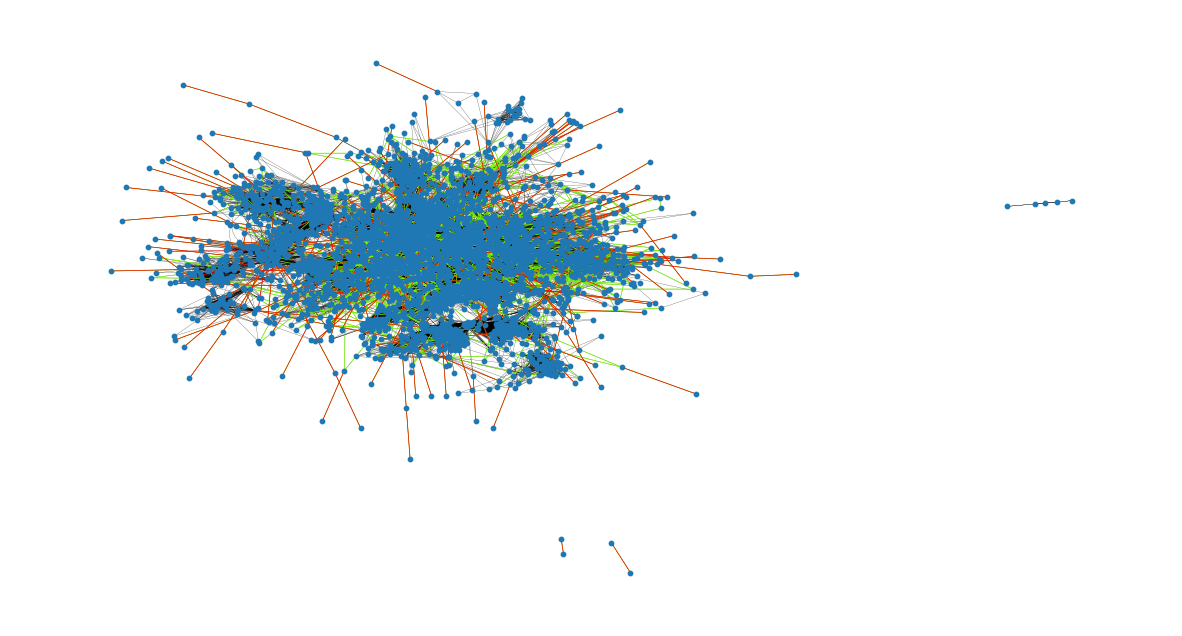

In [ ]:
plt.figure(figsize=(15, 8))
nx.draw_networkx(G, pos=pos, node_size=10, with_labels=False, width=0.15)
nx.draw_networkx_edges(
    G, pos, edgelist=local_bridges, width=0.5, edge_color="lawngreen"
)  # green color for local bridges
nx.draw_networkx_edges(
    G, pos, edgelist=bridges, width=0.5, edge_color="r"
)  # red color for bridges
plt.axis("off")

## Asortatividad
La asortatividad describe la preferencia de los nodos de una red a conectarse con otros que son similares de alguna manera.



In [ ]:
nx.degree_assortativity_coefficient(G)

0.07572773506976808

In [ ]:
nx.degree_pearson_correlation_coefficient(
    G
)  # use the potentially faster scipy.stats.pearsonr function.

0.07572773506976577

El hecho de que la asortatividad de una red sea de 0.075 y que el coeficiente de correlación de Pearson entre los grados de los nodos conectados también sea de 0.075 indica lo siguiente:

La asortatividad se mide con el coeficiente de correlación de Pearson: El coeficiente de asortatividad, cuando se refiere a la conexión entre nodos con grados similares, se calcula utilizando el coeficiente de correlación de Pearson de los grados de los nodos en los extremos de cada arista de la red.

Baja asortatividad positiva: Un valor de 0.075 indica una baja asortatividad positiva. Esto significa que existe una ligera tendencia a que los nodos con grados similares se conecten entre sí, pero esta tendencia no es muy fuerte.

Correlación lineal débil: El coeficiente de correlación de Pearson de 0.075 también indica una correlación lineal positiva débil entre los grados de los nodos conectados. Esto refuerza la idea de que, si bien hay una ligera preferencia por la conexión entre nodos de grado similar, esta relación no es muy pronunciada.

## Comunidades en la Red
Una comunidad es un grupo de nodos, de manera que los nodos dentro del grupo están conectados con muchas más aristas que entre grupos. Se utilizarán dos algoritmos diferentes para la detección de comunidades en esta red.

Esta función determina por sí misma el número de comunidades que se detectarán. Ahora se iterará a través de las comunidades y se creará una lista de colores para contener el mismo color para los nodos que pertenecen a la misma comunidad. También, se imprime el número de comunidades:"

In [ ]:
colors = ["" for x in range(max(G.nodes()) + 1)]  # initialize colors list with enough space
counter = 0
for com in nx.community.label_propagation_communities(G):
    color = "#%06X" % randint(0, 0xFFFFFF)  # creates random RGB color
    counter += 1
    for node in list(
        com
    ):  # fill colors list with the particular color for the community nodes
        colors[node] = color # assign color to node index in color list
counter

88

En detalle, se detectaron 88 comunidades.